validacion del modelo entrenado con tcga-brca contra geo gse25055

## configuracion del entorno django


In [32]:
import os
import sys

DJANGO_APP_PATH = "/home/ph0/MBIO/TFM/src/app"
sys.path.insert(0, DJANGO_APP_PATH)

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "project.settings")
os.environ.setdefault("POSTGRES_HOST", "localhost")
os.environ.setdefault("POSTGRES_DB", "tfg_db")
os.environ.setdefault("POSTGRES_USER", "postgres")
os.environ.setdefault("POSTGRES_PASSWORD", "password")
os.environ.setdefault("POSTGRES_PORT", "5432")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()
print("Django OK:", django.__version__)

Django OK: 6.0.5


## carga del conjunto de entrenamiento, tcga-brca (z-score)


In [33]:
import pandas as pd
import numpy as np
import time
from core.models import TCGAFile, TCGAExpressionRecord

# casos con etiqueta pam50
file_case_rows = list(
    TCGAFile.objects
    .filter(
        data_type="Gene Expression Quantification",
        cases__molecular_subtype__gt="",
    )
    .values("id", "file_id", "cases__id", "cases__molecular_subtype")
)
df_file_case = pd.DataFrame.from_records(file_case_rows)
df_file_case.columns = ["file_pk", "file_id", "case_pk", "molecular_subtype"]
df_file_case = df_file_case.drop_duplicates(subset="case_pk")
print(f"Ficheros TCGA disponibles: {len(df_file_case)}")
print(df_file_case["molecular_subtype"].value_counts())

Ficheros TCGA disponibles: 360
molecular_subtype
LumA      166
LumB       63
Normal     54
Basal      50
Her2       27
Name: count, dtype: int64


In [34]:
# cargar expresion
file_pks = df_file_case["file_pk"].tolist()
t0 = time.time()
expr_qs = (
    TCGAExpressionRecord.objects
    .filter(tcga_file_id__in=file_pks, gene_type="protein_coding")
    .values("tcga_file_id", "gene_name", "tpm_unstranded")
)
df_expr_tcga = pd.DataFrame.from_records(expr_qs)
print(f"Filas TCGA: {len(df_expr_tcga):,}  ({time.time()-t0:.1f}s)")

# pivotar
df_tcga = df_expr_tcga.pivot_table(
    index="tcga_file_id", columns="gene_name", values="tpm_unstranded", aggfunc="first"
)
# etiqueta
pk_to_subtype = df_file_case.set_index("file_pk")["molecular_subtype"].to_dict()
df_tcga["label"] = df_tcga.index.map(pk_to_subtype)
df_tcga = df_tcga.dropna(subset=["label"])
print(f"Matriz TCGA: {df_tcga.shape[0]} muestras x {df_tcga.shape[1]-1} genes")
print(df_tcga["label"].value_counts())

Filas TCGA: 4,411,602  (10.8s)
Matriz TCGA: 221 muestras x 19938 genes
label
LumA      106
LumB       39
Basal      31
Normal     30
Her2       15
Name: count, dtype: int64


In [35]:
# preprocesar
y_train = df_tcga["label"].values
X_raw = df_tcga.drop(columns=["label"]).values.astype(np.float32)
X_raw = np.nan_to_num(X_raw, nan=0.0)
X_log = np.log1p(X_raw)

tcga_gene_names = df_tcga.drop(columns=["label"]).columns.tolist()

# z-score por gen
tcga_mean = X_log.mean(axis=0)
tcga_std  = X_log.std(axis=0)
tcga_std[tcga_std == 0] = 1  # evitar division por cero
X_train_z = (X_log - tcga_mean) / tcga_std

print(f"X_train z-score: {X_train_z.shape}")
print(f"Clases: {sorted(set(y_train))}")

X_train z-score: (221, 19938)
Clases: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']


## seleccion de caracteristicas (top varianza en tcga)


In [36]:
TOP_GENES = 3000  # genes mas variables

# varianza antes del z-score
variances = X_log.var(axis=0)
top_idx = np.argsort(variances)[::-1][:TOP_GENES]
selected_genes = [tcga_gene_names[i] for i in top_idx]

X_train_sel = X_train_z[:, top_idx]
print(f"Features seleccionados: {len(selected_genes)}")
print(f"X_train final: {X_train_sel.shape}")

Features seleccionados: 3000
X_train final: (221, 3000)


## entrenamiento del clasificador en tcga


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

RANDOM_STATE = 42

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train_sel, y_train)
print("Modelo entrenado en TCGA (z-score).")

# cv de referencia
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train_sel, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"CV F1 macro TCGA (5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Modelo entrenado en TCGA (z-score).
CV F1 macro TCGA (5-fold): 0.7014 +/- 0.1079


## carga del conjunto de test geo gse25055 (z-score ya calculado)


In [38]:
from core.models import GEOSample, GEOExpressionRecord, GEOSeries

series = GEOSeries.objects.get(accession="GSE25055")
samples_qs = GEOSample.objects.filter(series=series)
print(f"Muestras GEO en BD: {samples_qs.count()}")

# muestras con etiqueta pam50
geo_samples_with_pam50 = [
    s for s in samples_qs
    if s.clinical_metadata.get("pam50_class")
]
print(f"Muestras con PAM50: {len(geo_samples_with_pam50)}")

from collections import Counter
print(Counter(s.clinical_metadata["pam50_class"] for s in geo_samples_with_pam50))

Muestras GEO en BD: 310
Muestras con PAM50: 310
Counter({'Basal': 122, 'LumA': 99, 'LumB': 44, 'Normal': 25, 'Her2': 20})


In [39]:
# cargar geo
geo_sample_ids = [s.id for s in geo_samples_with_pam50]
geo_id_to_pam50 = {s.id: s.clinical_metadata["pam50_class"] for s in geo_samples_with_pam50}

t0 = time.time()
geo_expr_qs = (
    GEOExpressionRecord.objects
    .filter(
        geo_sample_id__in=geo_sample_ids,
        gene_symbol__in=selected_genes,
    )
    .values("geo_sample_id", "gene_symbol", "zscore")
)
df_geo_expr = pd.DataFrame.from_records(geo_expr_qs)
print(f"Filas GEO cargadas: {len(df_geo_expr):,}  ({time.time()-t0:.1f}s)")

# pivotar
df_geo = df_geo_expr.pivot_table(
    index="geo_sample_id", columns="gene_symbol", values="zscore", aggfunc="first"
)
print(f"Matriz GEO: {df_geo.shape[0]} muestras x {df_geo.shape[1]} genes")

Filas GEO cargadas: 679,830  (5.9s)
Matriz GEO: 310 muestras x 2193 genes


In [40]:
# alinear columnas
df_geo = df_geo.reindex(columns=selected_genes, fill_value=0.0)
X_test_geo = np.nan_to_num(df_geo.values.astype(np.float32), nan=0.0)
y_test_geo = np.array([geo_id_to_pam50[sid] for sid in df_geo.index])

# genes en comun
common = df_geo_expr["gene_symbol"].nunique()
print(f"Genes en comun TCGA & GEO: {common} de {TOP_GENES} seleccionados")
print(f"X_test_geo: {X_test_geo.shape}")
print(f"Distribucion PAM50 GEO test: {Counter(y_test_geo)}")

Genes en comun TCGA & GEO: 2193 de 3000 seleccionados
X_test_geo: (310, 3000)
Distribucion PAM50 GEO test: Counter({np.str_('Basal'): 122, np.str_('LumA'): 99, np.str_('LumB'): 44, np.str_('Normal'): 25, np.str_('Her2'): 20})


## validacion cross-platform


In [41]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_geo = rf.predict(X_test_geo)

acc_cross  = accuracy_score(y_test_geo, y_pred_geo)
f1_cross   = f1_score(y_test_geo, y_pred_geo, average="macro")
y_proba_geo = rf.predict_proba(X_test_geo)
auc_cross  = roc_auc_score(y_test_geo, y_proba_geo, multi_class="ovr", average="macro")
report_cross = classification_report(y_test_geo, y_pred_geo)

print("VALIDACION CROSS-PLATFORM TCGA, GEO GSE25055\n")
print(f"Accuracy: {acc_cross:.4f}")
print(f"F1 macro: {f1_cross:.4f}")
print(f"AUC macro (ovr): {auc_cross:.4f}")
print()
print(report_cross)

VALIDACION CROSS-PLATFORM TCGA, GEO GSE25055

Accuracy: 0.6097
F1 macro: 0.4567
AUC macro (ovr): 0.8922

              precision    recall  f1-score   support

       Basal       1.00      0.49      0.66       122
        Her2       1.00      0.10      0.18        20
        LumA       0.52      1.00      0.68        99
        LumB       0.52      0.55      0.53        44
      Normal       0.40      0.16      0.23        25

    accuracy                           0.61       310
   macro avg       0.69      0.46      0.46       310
weighted avg       0.73      0.61      0.58       310



locator: <matplotlib.ticker.AutoLocator object at 0x753b245f7020>
Assigning font /F1 (subset 0) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):0.
Writing TrueType font.


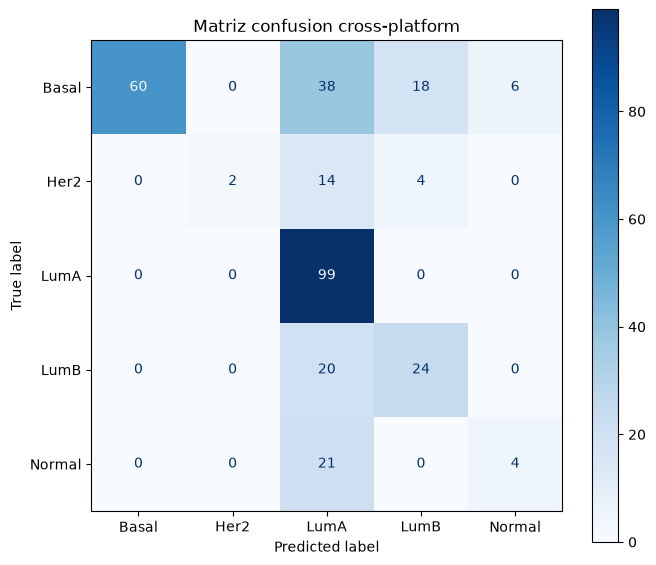

In [42]:
labels_all = sorted(set(y_test_geo))
cm_cross = confusion_matrix(y_test_geo, y_pred_geo, labels=labels_all)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cross, display_labels=labels_all)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Matriz confusion cross-platform")
plt.tight_layout()
plt.savefig("../tex/figures/confusion_matrix_crossplatform.pdf", dpi=150)
plt.show()

## comparacion tcga-only vs cross-platform


In [43]:
# referencia tcga
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_sel, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
rf_ref = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                n_jobs=-1, random_state=RANDOM_STATE)
rf_ref.fit(X_tr, y_tr)
y_pred_tcga_test = rf_ref.predict(X_te)

acc_tcga  = accuracy_score(y_te, y_pred_tcga_test)
f1_tcga   = f1_score(y_te, y_pred_tcga_test, average="macro")
y_proba_tcga = rf_ref.predict_proba(X_te)
auc_tcga  = roc_auc_score(y_te, y_proba_tcga, multi_class="ovr", average="macro")

print("Comparacion de rendimiento:")
print(f"TCGA a TCGA (test interno 20%):  Accuracy={acc_tcga:.4f}  F1 macro={f1_tcga:.4f}  AUC={auc_tcga:.4f}")
print(f"TCGA a GEO (cross-platform):  Accuracy={acc_cross:.4f}  F1 macro={f1_cross:.4f}  AUC={auc_cross:.4f}")
print(f"Caida de accuracy cross-platform: {(acc_tcga - acc_cross)*100:.1f} pp")
print(f"Caida de F1 macro cross-platform: {(f1_tcga - f1_cross)*100:.1f} pp")

Comparacion de rendimiento:
TCGA a TCGA (test interno 20%):  Accuracy=0.6889  F1 macro=0.6333  AUC=0.8575
TCGA a GEO (cross-platform):  Accuracy=0.6097  F1 macro=0.4567  AUC=0.8922
Caida de accuracy cross-platform: 7.9 pp
Caida de F1 macro cross-platform: 17.7 pp


Assigning font /F1 (subset 0) = FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0)
Embedding font FontPath('/home/ph0/miniconda3/envs/tfm/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', 0):0.
Writing TrueType font.


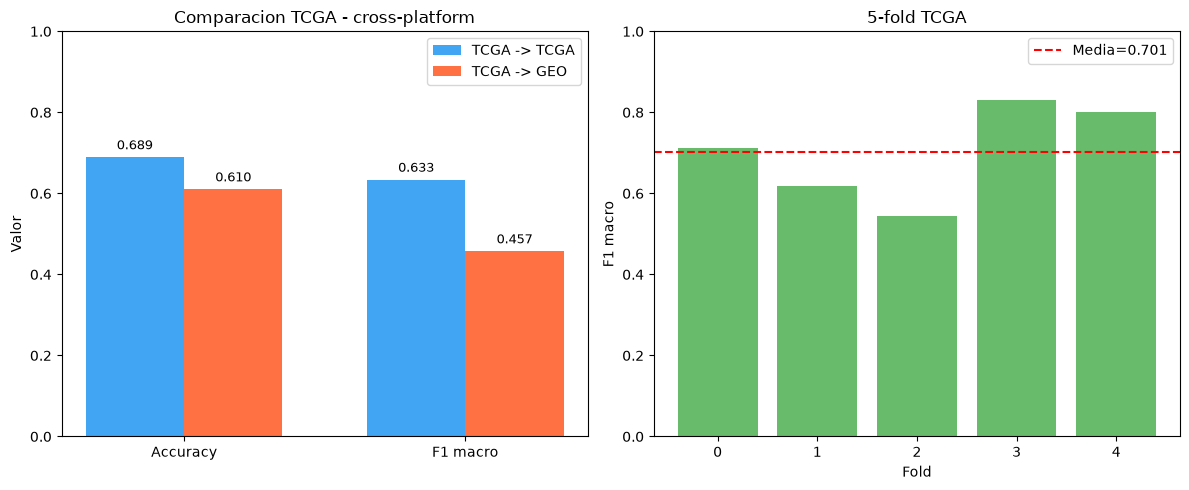

In [44]:
# grafico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# barras
metrics = ["Accuracy", "F1 macro"]
tcga_vals  = [acc_tcga,  f1_tcga]
cross_vals = [acc_cross, f1_cross]

x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, tcga_vals,  width, label="TCGA -> TCGA",  color="#2196F3", alpha=0.85)
axes[0].bar(x + width/2, cross_vals, width, label="TCGA -> GEO",   color="#FF5722", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Valor")
axes[0].set_title("Comparacion TCGA - cross-platform")
axes[0].legend()
for i, (tv, cv) in enumerate(zip(tcga_vals, cross_vals)):
    axes[0].text(i - width/2, tv + 0.02, f"{tv:.3f}", ha="center", fontsize=9)
    axes[0].text(i + width/2, cv + 0.02, f"{cv:.3f}", ha="center", fontsize=9)

# cv scores
axes[1].bar(range(len(cv_scores)), cv_scores, color="#4CAF50", alpha=0.85)
axes[1].axhline(cv_scores.mean(), color="red", linestyle="--", label=f"Media={cv_scores.mean():.3f}")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("F1 macro")
axes[1].set_title(f"5-fold TCGA")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../tex/figures/crossplatform_comparison.pdf", dpi=150)
plt.show()

## resumen final


In [45]:
print("RESUMEN VALIDACION CROSS-PLATFORM PAM50")
print(f"Train: {X_train_sel.shape[0]} muestras TCGA-BRCA RNA-seq")
print(f"Test: {X_test_geo.shape[0]} muestras GEO GSE25055 microarray")
print(f"Genes comunes (top varianza TCGA): {common} de {TOP_GENES}")
print()
print(f"TCGA a TCGA (80/20 split):")
print(f"  Accuracy: {acc_tcga:.4f}")
print(f"  F1 macro: {f1_tcga:.4f}")
print(f"  CV F1 macro (5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print()
print(f"TCGA a GEO (cross-platform):")
print(f"  Accuracy: {acc_cross:.4f}")
print(f"  F1 macro: {f1_cross:.4f}")
print()
print("Figuras guardadas:")
print("  tex/figures/confusion_matrix_crossplatform.pdf")
print("  tex/figures/crossplatform_comparison.pdf")

RESUMEN VALIDACION CROSS-PLATFORM PAM50
Train: 221 muestras TCGA-BRCA RNA-seq
Test: 310 muestras GEO GSE25055 microarray
Genes comunes (top varianza TCGA): 2193 de 3000

TCGA a TCGA (80/20 split):
  Accuracy: 0.6889
  F1 macro: 0.6333
  CV F1 macro (5-fold): 0.7014 +/- 0.1079

TCGA a GEO (cross-platform):
  Accuracy: 0.6097
  F1 macro: 0.4567

Figuras guardadas:
  tex/figures/confusion_matrix_crossplatform.pdf
  tex/figures/crossplatform_comparison.pdf


In [46]:
# resumen numerico
print("RESUMEN NUMERICO COMPLETO\n")
print(f"TCGA muestras con PAM50 y TSV : 221")
print(f"Genes protein_coding          : {X_raw.shape[1]}")
print(f"Features seleccionados        : {TOP_GENES}")
print(f"TCGA a TCGA accuracy          : {acc_tcga:.4f}")
print(f"TCGA a TCGA F1 macro          : {f1_tcga:.4f}")
print(f"CV F1 macro 5-fold            : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Scores por fold               : {[round(s,4) for s in cv_scores]}")
print()
print(f"GEO muestras                  : {len(y_test_geo)}")
print(f"Genes comunes TCGA y GEO      : {common} de {TOP_GENES} ({common/TOP_GENES*100:.1f}%)")
print(f"TCGA a GEO accuracy           : {acc_cross:.4f}")
print(f"TCGA a GEO F1 macro           : {f1_cross:.4f}")
print(f"Caida accuracy                : {(acc_tcga - acc_cross)*100:.1f} pp")
print(f"Caida F1 macro                : {(f1_tcga - f1_cross)*100:.1f} pp")

RESUMEN NUMERICO COMPLETO

TCGA muestras con PAM50 y TSV : 221
Genes protein_coding          : 19938
Features seleccionados        : 3000
TCGA a TCGA accuracy          : 0.6889
TCGA a TCGA F1 macro          : 0.6333
CV F1 macro 5-fold            : 0.7014 +/- 0.1079
Scores por fold               : [np.float64(0.713), np.float64(0.618), np.float64(0.5446), np.float64(0.8303), np.float64(0.8011)]

GEO muestras                  : 310
Genes comunes TCGA y GEO      : 2193 de 3000 (73.1%)
TCGA a GEO accuracy           : 0.6097
TCGA a GEO F1 macro           : 0.4567
Caida accuracy                : 7.9 pp
Caida F1 macro                : 17.7 pp
